# Entrenamiento de un modelo LeNet-5 para clasificación de audio usando espectrogramas

En este Notebook se entrena una red convolucional tipo **LeNet-5** adaptada para trabajar con espectrogramas generados a partir de audios del dataset **ESC-50**. El objetivo es construir y entrenar este modelo desde cero utilizando PyTorch, convertir los audios a espectrogramas y evaluar su rendimiento en tareas de clasificación multiclase.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import soundfile as sf
from tqdm import tqdm
import wandb

### Carga y preparación de los datos

En esta sección cargamos el conjunto de datos y lo preparamos para el entrenamiento. Usamos utilidades de PyTorch para descargar las imágenes, aplicar transformaciones básicas y convertirlas a tensores. Luego creamos data loaders, que nos permiten alimentar los datos al modelo en pequeños lotes durante el entrenamiento para hacerlo más eficiente.

In [2]:
DATASET_PATH = "./ESC-50-master"
AUDIO_PATH = os.path.join(DATASET_PATH, "audio")
META_FILE = os.path.join(DATASET_PATH, "meta/esc50.csv")
df = pd.read_csv(META_FILE)
df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


La tabla corresponde a las primeras filas del archivo de metadatos del dataset (el archivo CSV). Cada fila representa un archivo de audio y muestra información como su nombre (`filename`), la categoría de sonido (`category`), una etiqueta numérica (`target`), el fold de validación (`fold`) y otros detalles del dataset. Esta tabla nos confirma que los datos se cargaron correctamente.

### Visualización de un ejemplo de audio

En esta celda cargamos un archivo de sonido del dataset para escuchar y observar su forma de onda. Esto nos ayuda a entender cómo luce un audio en el dominio del tiempo antes de procesarlos. Luego, graficamos la señal para ver cómo varía la amplitud del sonido a lo largo del tiempo.

In [3]:
def load_audio(path):
    waveform, sr = sf.read(path)

    # Asegurar float32
    if waveform.dtype != "float32":
        waveform = waveform.astype("float32")

    # Convertir a tensor
    waveform = torch.from_numpy(waveform).float()

    # Si es estéreo → convertir a mono
    if len(waveform.shape) > 1:
        waveform = torch.mean(waveform, dim=1)

    waveform = waveform.unsqueeze(0)  # Forma [1, num_samples]
    return waveform, sr

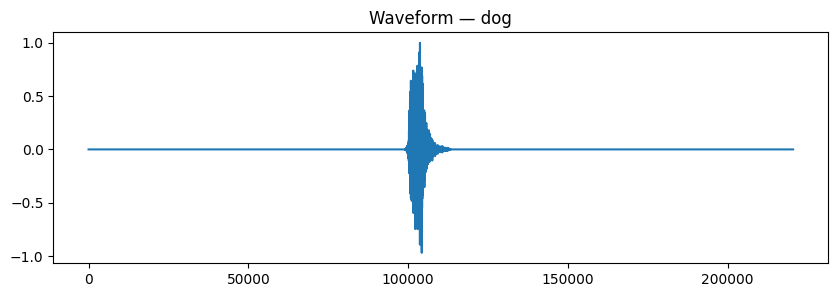

Sample rate: 44100 Waveform shape: torch.Size([1, 220500])


In [4]:
test_file = os.path.join(AUDIO_PATH, df.iloc[0]["filename"])
waveform, sr = load_audio(test_file)
plt.figure(figsize=(10, 3))
plt.plot(waveform.squeeze().numpy())
plt.title(f"Waveform — {df.iloc[0]['category']}")
plt.show()
print("Sample rate:", sr, "Waveform shape:", waveform.shape)

Aquí graficamos la forma de onda del archivo de audio seleccionado. La forma de onda permite visualizar cómo varía la amplitud de la señal a lo largo del tiempo, lo cual nos ayuda a entender el comportamiento del sonido, identificar picos, silencios o patrones característicos antes de procesarlo para el modelo.

La salida nos muestra información básica del audio cargado. El `sample rate` indica que el sonido fue grabado a 44,100 muestras por segundo, que es la frecuencia estándar en audio digital. El `waveform shape` revela que el archivo contiene un único canal (audio mono) y un total de 220,500 muestras, lo que corresponde a aproximadamente 5 segundos de audio.

### Definición del dataset personalizado

Aquí definimos una clase `ESC50Dataset` que nos permite cargar los audios del dataset ESC-50 y convertirlos en espectrogramas Mel. Cada vez que se solicita un dato, esta clase carga el archivo de audio, lo convierte en un Mel-spectrogram en decibeles y devuelve tanto esta representación como la etiqueta correspondiente. Esto nos permite usar el dataset fácilmente dentro de PyTorch para entrenar el modelo.

In [5]:
class ESC50Dataset(Dataset):
    def __init__(self, df, base_path, n_mels=128, transform=None):
        self.df = df
        self.base_path = base_path
        self.transform = transform
        self.n_mels = n_mels

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.base_path, row["filename"])
        waveform, sr = load_audio(file_path)

        # Convertir a mel-spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=waveform.squeeze().numpy(), sr=sr, n_mels=self.n_mels
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        mel_spec_db = torch.tensor(mel_spec_db).unsqueeze(0)  # [1, n_mels, time]

        label = row["target"]
        return mel_spec_db, label

### División del dataset y creación de loaders

En esta sección dividimos el dataset original en tres partes: entrenamiento, validación y prueba. Usamos `stratify` para asegurarnos de que cada grupo mantenga la misma proporción de clases. Luego, creamos objetos `Dataset` para cada partición y los cargamos en `DataLoader`, que se encarga de entregar los datos en lotes (batches) durante el entrenamiento.


In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.1, stratify=train_df["target"], random_state=42)

train_dataset = ESC50Dataset(train_df, AUDIO_PATH)
val_dataset = ESC50Dataset(val_df, AUDIO_PATH)
test_dataset = ESC50Dataset(test_df, AUDIO_PATH)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Definición del modelo LeNet5 adaptado

Aquí definimos nuestra red neuronal basada en la arquitectura clásica LeNet-5, adaptada para trabajar con espectrogramas de audio.  

El modelo usa capas convolucionales y de pooling para extraer características del espectrograma, seguidas de capas totalmente conectadas para clasificar el sonido en una de las 50 categorías del dataset ESC-50.  

Además, la primera capa fully-connected se ajusta dinámicamente según el tamaño real de la entrada, ya que la duración de los audios puede generar espectrogramas con diferentes dimensiones.

In [7]:
class LeNet5Audio(nn.Module):
    def __init__(self, num_classes=50):
        super(LeNet5Audio, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.AvgPool2d(2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(1, 120)  # temporal, se reemplaza dinámicamente
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # flatten
        # dinámicamente ajusta fc1 si es la primera pasada
        if self.fc1.in_features != x.size(1):
            self.fc1 = nn.Linear(x.size(1), 120).to(x.device)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Funciones de entrenamiento y validación

Aquí definimos dos funciones para entrenar el modelo y evaluar su desempeño después de cada época:

- **train_one_epoch**: ejecuta una pasada completa por el conjunto de entrenamiento. Calcula la pérdida, realiza backpropagation y actualiza los pesos del modelo. También lleva el registro de la precisión y el error acumulado.

- **validate**: evalúa el modelo en el conjunto de validación sin actualizar los pesos. Esto ayuda a verificar si el modelo está aprendiendo correctamente o si comienza a sobreajustarse.

In [8]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss/total, correct/total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss/total, correct/total

### Entrenamiento del modelo y registro con Weights & Biases

En esta parte iniciamos el entrenamiento del modelo LeNet-5. Primero configuramos el dispositivo de cómputo (CPU o GPU si estuviera disponible) y definimos los parámetros principales de entrenamiento, como la tasa de aprendizaje, número de épocas y tamaño de lote. Luego, entrenamos el modelo iterando por cada época, calculando métricas de rendimiento tanto para entrenamiento como para validación. 

Utilizamos **Weights & Biases** para hacer el registro automático del progreso de entrenamiento, incluyendo precisión y pérdida. Esto permite visualizar el comportamiento del modelo en tiempo real y analizar fácilmente si está aprendiendo adecuadamente o si presenta problemas como sobreajuste.

In [9]:
PROJECT_NAME = "esc50-lenet-cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

wandb.init(project=PROJECT_NAME, config={
    "lr": 0.01,
    "batch_size": 32,
    "epochs": 30,
    "model": "LeNet5Audio",
})

model = LeNet5Audio().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=wandb.config.lr, momentum=0.9)

for epoch in range(wandb.config.epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    wandb.log({
        "epoch": epoch+1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc
    })
    
    print(f"Epoch {epoch+1}/{wandb.config.epochs} | "
          f"Train Acc: {train_acc:.3f} | Val Acc: {val_acc:.3f}")

wandb.finish()

Training on: cpu


wandb: Currently logged in as: kgrioghar (kgrioghar-tecnol-gico-de-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


100%|██████████████████████████████████████████████████████████████████████████████████| 45/45 [00:40<00:00,  1.12it/s]


Epoch 1/30 | Train Acc: 0.016 | Val Acc: 0.019


100%|██████████████████████████████████████████████████████████████████████████████████| 45/45 [00:24<00:00,  1.83it/s]


...

100%|██████████████████████████████████████████████████████████████████████████████████| 45/45 [00:24<00:00,  1.87it/s]


Epoch 29/30 | Train Acc: 0.380 | Val Acc: 0.094


100%|██████████████████████████████████████████████████████████████████████████████████| 45/45 [00:24<00:00,  1.87it/s]


Epoch 30/30 | Train Acc: 0.403 | Val Acc: 0.094


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
train_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▅▆▇▇▇██▇█
train_loss,██████████████▇▇▇▆▅▅▄▃▃▂▂▂▁▁▂▁
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▄▅▆▅▆▇▄█▃█▆█▅▅
val_loss,▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▂▂▂▂▃▄▃▄▃▇█
epoch,30
train_acc,0.40278
train_loss,2.20693
val_acc,0.09375
val_loss,6.5893


### Resultados del entrenamiento

Durante 30 épocas, el modelo fue mejorando gradualmente: empezó con una precisión casi nula y terminó alcanzando alrededor de **40% de exactitud en entrenamiento** y cerca de **9% en validación**.

Esto indica que el modelo aprendió ciertos patrones del conjunto de entrenamiento, pero aún no generaliza bien a datos que no ha visto (validación). También se observa cómo las curvas de pérdida y precisión evolucionan a lo largo del entrenamiento, lo que ayuda a entender el comportamiento del modelo y detectar posibles problemas como sobreajuste o aprendizaje lento.


### Resultados en el conjunto de prueba (Test Set)

Finalmente, evaluamos el modelo utilizando el conjunto de prueba, es decir, datos completamente nuevos que no fueron utilizados durante entrenamiento ni validación. Esto nos permite medir qué tan bien generaliza el modelo en un escenario real.

In [10]:
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.3f}, Test Loss: {test_loss:.3f}")

Test Accuracy: 0.117, Test Loss: 5.993



El modelo alcanzó una **precisión del 11.7%** en el conjunto de prueba. Aunque este desempeño es bajo, es coherente con los resultados observados durante la validación. Esto indica que el modelo aún no está capturando adecuadamente los patrones necesarios para clasificar correctamente los audios en las diferentes categorías.

Este resultado es típico en entrenamientos iniciales con arquitecturas simples y configuraciones básicas.